# **Data Collection**

In [4]:
!pip install -U kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

C:\Users\SOUMYOJEET\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import pandas as pd
print(pd.__version__)

3.0.5


In [7]:
file_path = "yield_df.csv"

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "patelris/crop-yield-prediction-dataset",
  file_path
)

data.head()

C:\Users\SOUMYOJEET\AppData\Local\Temp\ipykernel_11780\3042820732.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## **Feature Extraction**

In [8]:
data = data.loc[:, 'Item':].drop('Year', axis=1)
data.head()

,Item,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,36613,1485.0,121.0,16.37
1,Potatoes,66667,1485.0,121.0,16.37
2,"Rice, paddy",23333,1485.0,121.0,16.37
3,Sorghum,12500,1485.0,121.0,16.37
4,Soybeans,7000,1485.0,121.0,16.37


In [9]:
X = data.drop('hg/ha_yield', axis=1)
Y = data['hg/ha_yield']
X.head()

,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,1485.0,121.0,16.37
1,Potatoes,1485.0,121.0,16.37
2,"Rice, paddy",1485.0,121.0,16.37
3,Sorghum,1485.0,121.0,16.37
4,Soybeans,1485.0,121.0,16.37


In [10]:
Y.head()

0    36613
1    66667
2    23333
3    12500
4     7000
Name: hg/ha_yield, dtype: int64

## **Data Analysis**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

<module 'matplotlib.pyplot' from 'C:\\Users\\SOUMYOJEET\\AppData\\Roaming\\Python\\Python311\\site-packages\\matplotlib\\pyplot.py'>

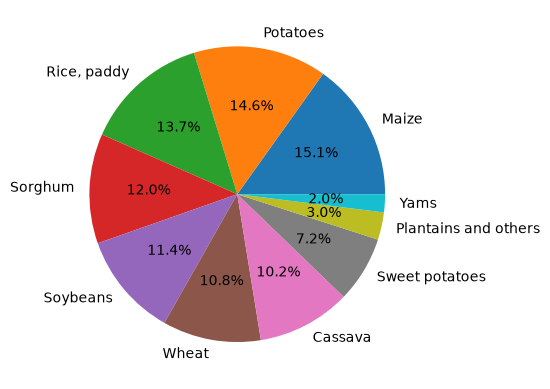

In [11]:
labels_crop  = X['Item'].unique()
plt.pie(X['Item'].value_counts(), labels=labels_crop, autopct='%1.1f%%')
plt

- May perform bad for  Yams, Plantains and others

In [12]:
data.describe()

,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.00000,28242.000000,28242.000000
mean,77053.332094,1149.05598,37076.909344,20.542627
std,84956.612897,709.81215,59958.784665,6.312051
min,50.000000,51.00000,0.040000,1.300000
25%,19919.250000,593.00000,1702.000000,16.702500
50%,38295.000000,1083.00000,17529.440000,21.510000
75%,104676.750000,1668.00000,48687.880000,26.000000
max,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:
labels_crop

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

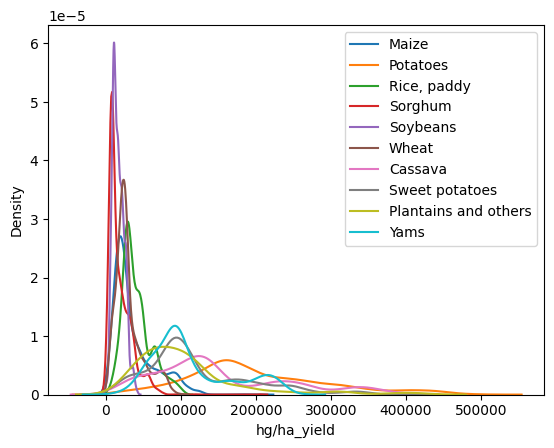

In [ ]:
# Comparative analysis on Y for crop types
for crop in labels_crop:
  sns.kdeplot(data[data['Item'] == crop]['hg/ha_yield'], label = crop)
plt.legend()

- Potatao, Yams, Plantanis, Cassava, Sweet Potatoes give always high (100000 < ) range

In [16]:
# Recording the max yeild of
crop_highest_yeild = [data[data['Item'] == crop]['hg/ha_yield'].max() for crop in labels_crop]

# Creating the df
crop_highest_yeild_df = pd.DataFrame({'Crop': labels_crop, 'Highest Yeild': crop_highest_yeild})

# Sorting the df based on Highest Yeild
crop_highest_yeild_df = crop_highest_yeild_df.sort_values(by='Highest Yeild', ascending=False)
crop_highest_yeild_df.reset_index(drop=True, inplace=True)

crop_highest_yeild_df

,Crop,Highest Yeild
0,Potatoes,501412
1,Plantains and others,418505
2,Sweet potatoes,400000
3,Cassava,385818
4,Yams,250000
5,Maize,207556
6,Sorghum,206000
7,"Rice, paddy",103895
8,Wheat,99387
9,Soybeans,41609


In [17]:
sorted_crop_names = crop_highest_yeild_df['Crop'].values
sorted_crop_names

<StringArray>
[            'Potatoes', 'Plantains and others',       'Sweet potatoes',
              'Cassava',                 'Yams',                'Maize',
              'Sorghum',          'Rice, paddy',                'Wheat',
             'Soybeans']
Length: 10, dtype: str

- Index of the particular crop type in the df needs to be its corresponding numerical value

<Axes: xlabel='average_rain_fall_mm_per_year', ylabel='hg/ha_yield'>

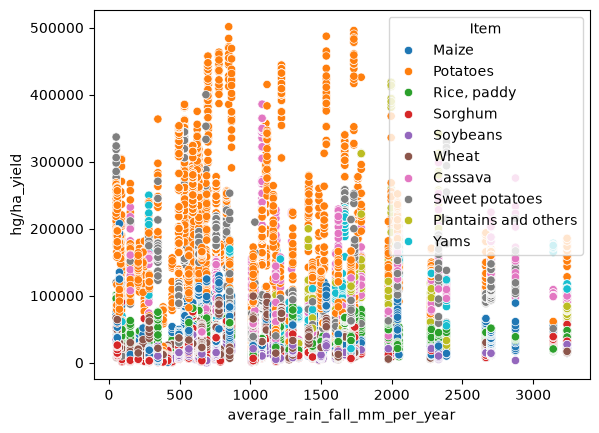

In [13]:
# Linearity find between Y and X[average_rain_fall_mm_per_year]
sns.scatterplot(x=X['average_rain_fall_mm_per_year'], y=Y, hue=X['Item'])


<Axes: xlabel='pesticides_tonnes', ylabel='hg/ha_yield'>

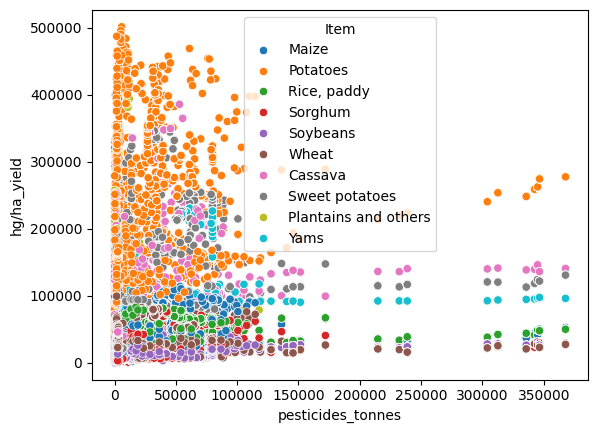

In [ ]:
# Linearity find between Y and X[pesticides_tonnes]
sns.scatterplot(x=X['pesticides_tonnes'], y=Y, hue=X['Item'])

<Axes: xlabel='avg_temp', ylabel='hg/ha_yield'>

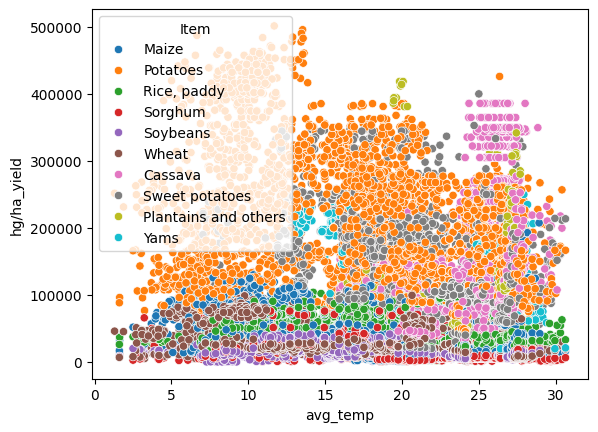

In [ ]:
# Linearity find between Y and X[avg_temp]
sns.scatterplot(x=X['avg_temp'], y=Y, hue=X['Item'])

In [ ]:
# 3D Plot
px.scatter_3d(x= X['average_rain_fall_mm_per_year'], y=X['avg_temp'], z = Y)

## **Outliers**

<Axes: xlabel='Item', ylabel='hg/ha_yield'>

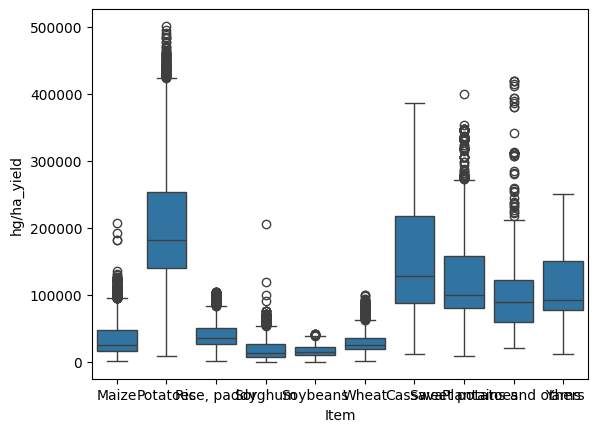

In [ ]:
# Outliers in y
sns.boxplot(x=X['Item'], y=Y)

<Axes: xlabel='average_rain_fall_mm_per_year'>

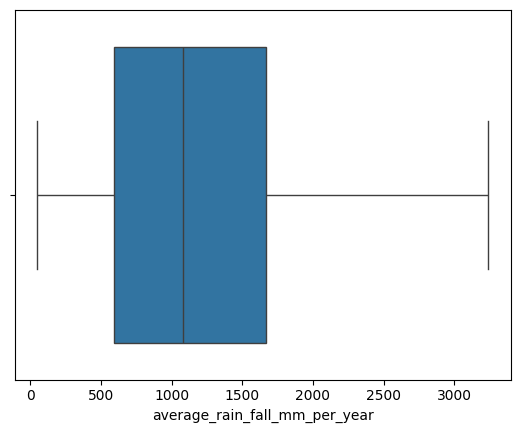

In [ ]:
# Outliers in
sns.boxplot(x=X['average_rain_fall_mm_per_year'])


<Axes: xlabel='pesticides_tonnes'>

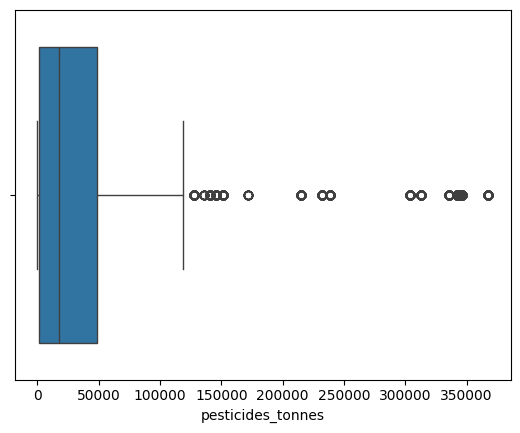

In [ ]:
sns.boxplot(x=X['pesticides_tonnes'])

<Axes: xlabel='avg_temp'>

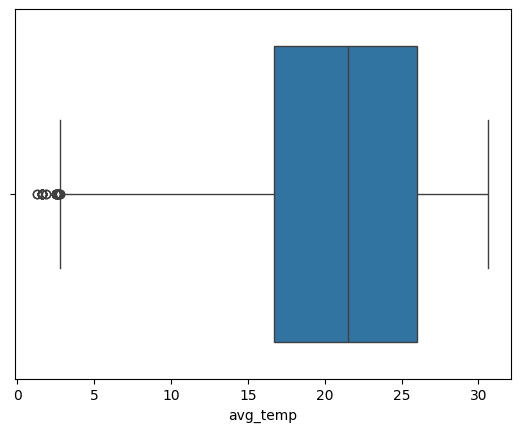

In [ ]:
sns.boxplot(x=X['avg_temp'])

In [18]:
# Outliers capping in X['pesticides_tonnes']

# IQR range
percentile75 = X['pesticides_tonnes'].quantile(0.75)
percentile25 = X['pesticides_tonnes'].quantile(0.25)
iqr = percentile75 - percentile25


# limit define
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

lower_limit, upper_limit

# Outliers at right
X_capped = X.copy()
X_capped['pesticides_tonnes'] = np.where(X['pesticides_tonnes'] > upper_limit, upper_limit, X['pesticides_tonnes'])
X_capped.shape

(28242, 4)

In [19]:
# Outliers capping in X['avg_temp']

# IQR range
percentile75 = X['avg_temp'].quantile(0.75)
percentile25 = X['avg_temp'].quantile(0.25)
iqr = percentile75 - percentile25


# limit define
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Outliers at left
X_capped['avg_temp'] = np.where(X['avg_temp'] < lower_limit , lower_limit, X['avg_temp'])
X_capped.shape

(28242, 4)

## **Features Corellation Identifying**

<Axes: >

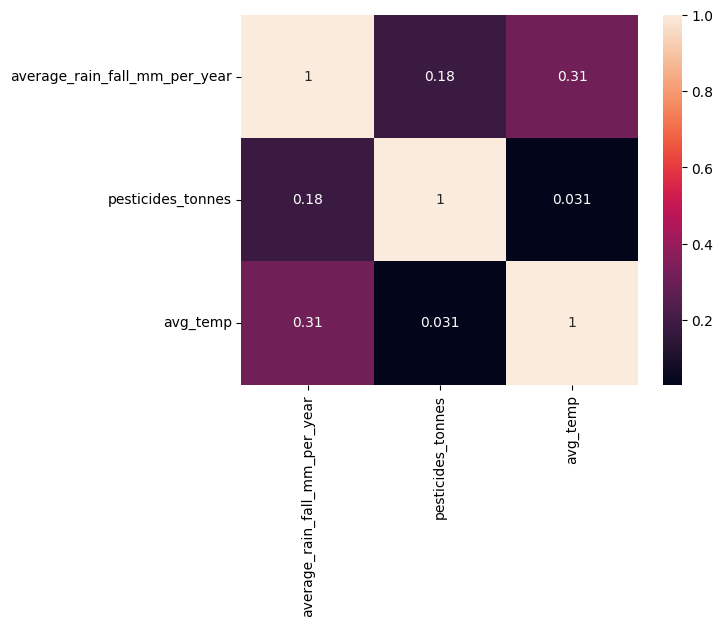

In [ ]:
corr_mat = X.drop(columns=['Item']).corr()
sns.heatmap(corr_mat, annot=True)

- No feature is highly corellated to other

## **Corellation With Y**

<Axes: >

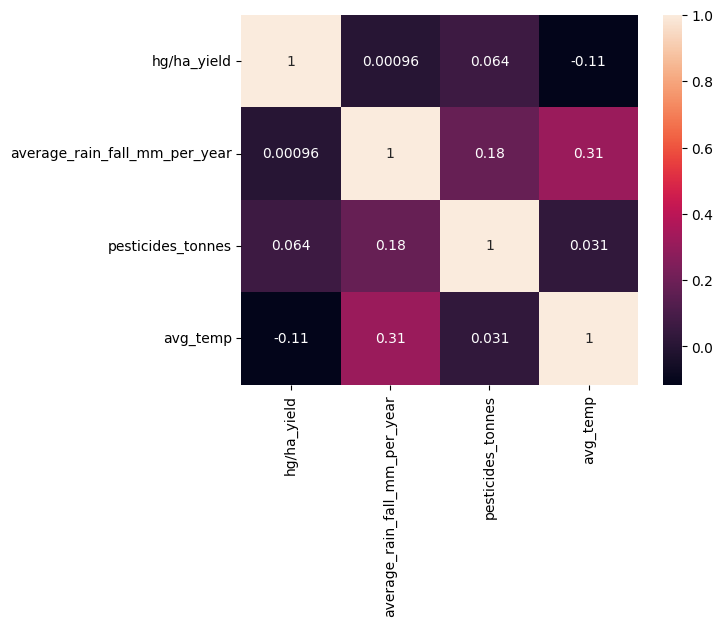

In [ ]:
sns.heatmap(data.drop(columns=['Item']).corr(), annot=True)

## **Feature Transformation**

In [14]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [20]:
X_capped.head()

,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,1485.0,121.0,16.37
1,Potatoes,1485.0,121.0,16.37
2,"Rice, paddy",1485.0,121.0,16.37
3,Sorghum,1485.0,121.0,16.37
4,Soybeans,1485.0,121.0,16.37


In [21]:
encoder = ColumnTransformer([
        ('ordinal_encoder', OrdinalEncoder(categories=[sorted_crop_names]), ['Item']) # Changed 'Item' to ['Item']
    ], remainder='passthrough')

X_transformed = encoder.fit_transform(X_capped)

X_transformed

array([[5.00000e+00, 1.48500e+03, 1.21000e+02, 1.63700e+01],
       [0.00000e+00, 1.48500e+03, 1.21000e+02, 1.63700e+01],
       [7.00000e+00, 1.48500e+03, 1.21000e+02, 1.63700e+01],
       ...,
       [9.00000e+00, 6.57000e+02, 2.55007e+03, 1.97600e+01],
       [2.00000e+00, 6.57000e+02, 2.55007e+03, 1.97600e+01],
       [8.00000e+00, 6.57000e+02, 2.55007e+03, 1.97600e+01]],
      shape=(28242, 4))

In [22]:
sc = StandardScaler()
X_transfored_scaled = sc.fit_transform(X_transformed)
X_transfored_scaled

array([[ 0.03467055,  0.47329419, -0.89886992, -0.66140646],
       [-1.63455138,  0.47329419, -0.89886992, -0.66140646],
       [ 0.70235932,  0.47329419, -0.89886992, -0.66140646],
       ...,
       [ 1.37004808, -0.69323228, -0.82639631, -0.12414876],
       [-0.96686261, -0.69323228, -0.82639631, -0.12414876],
       [ 1.0362037 , -0.69323228, -0.82639631, -0.12414876]],
      shape=(28242, 4))

## **Train Test Split**

In [23]:
X_capped.head()

,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,1485.0,121.0,16.37
1,Potatoes,1485.0,121.0,16.37
2,"Rice, paddy",1485.0,121.0,16.37
3,Sorghum,1485.0,121.0,16.37
4,Soybeans,1485.0,121.0,16.37


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X_transfored_scaled, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((22593, 4), (5649, 4), (22593,), (5649,))

In [26]:
X_train

array([[ 0.36851493,  0.64094715, -0.87772846,  0.7633566 ],
       [ 1.37004808, -0.09306286,  1.20963654,  0.8505223 ],
       [-0.63301822,  0.20138645, -0.88802186,  0.83467399],
       ...,
       [-1.63455138, -0.86652063, -0.36943102, -0.28738635],
       [-0.96686261, -0.44668381,  1.32379485, -1.30960233],
       [-0.96686261, -0.41568914, -0.44267827, -0.70578173]],
      shape=(22593, 4))

## ***Models Selection***

In [28]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 660.6 kB/s eta 0:02:34
   ---------------------------------------- 0.2/101.7 MB 2.4 MB/s eta 0:00:43
   ---------------------------------------- 0.6/101.7 MB 4.5 MB/s eta 0:00:23
   ---------------------------------------- 0.8/101.7 MB 4.6 MB/s eta 0:00:23
   ---------------------------------------- 1.0/101.7 MB 4.4 MB/s eta 0:00:23
   ---------------------------------------- 1.2/101.7 MB 4.3 MB/s eta 0:00:24
    --------------------------------------- 1.4/101.7 MB 4.2 MB/s eta 0:00:24
    --------------------------------------- 1.5/101.7 MB 4.3 MB/s eta 0:00:24
    --------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [30]:
def evaluate_model(true, predicted):
  mae = mean_absolute_error(true, predicted)
  mse = mean_squared_error(true, predicted)
  r2 = r2_score(true, predicted)
  return {'mae': mae, 'mse': mse, 'r2': r2}

def cross_validation(model, X, Y):
  scores = cross_val_score(model, X, Y, cv=5)
  return scores.mean()

## **1. LR**

In [31]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 40287.96490916229, 'mse': 3181980906.725, 'r2': 0.5613282597413317}

In [32]:
cross_validation(lr, X_train, Y_train)

np.float64(0.5504320194039769)

## **2. RFR**

In [33]:
rfr = RandomForestRegressor()
rfr.fit(X_train, Y_train)

Y_pred = rfr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 6368.629796298424, 'mse': 221380258.64627892, 'r2': 0.9694802495156297}

In [34]:
cross_validation(rfr, X_train, Y_train)

np.float64(0.9669106502591852)

## **3. DTR**

In [35]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, Y_train)

Y_pred = dtr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 7044.555437540567, 'mse': 381170573.37829703, 'r2': 0.9474513632668686}

In [36]:
cross_validation(dtr, X_train, Y_train)

np.float64(0.9432375985131222)

## **4. SVR**

In [37]:
svr = SVR()
svr.fit(X_train, Y_train)

Y_pred = svr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 56358.2866894715, 'mse': 8535506661.147953, 'r2': -0.1767152823330329}

In [38]:
cross_validation(svr, X_train, Y_train)

np.float64(-0.18342487959451037)

## **5. XGB**

In [39]:
xgb = XGBRegressor()
xgb.fit(X_train, Y_train)

Y_pred = xgb.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 8769.873046875, 'mse': 259275664.0, 'r2': 0.9642559289932251}

In [40]:
cross_validation(xgb, X_train, Y_train)


np.float64(0.9621197342872619)

---
### ***Selecting XGB as the final model***
- It gives
  - High r2
  - High cross_val_score
  - cross_val_score ~ r2 -> no overfitting
  - Low latency
---

## **Pipeline**

In [41]:
xgb.predict(X_test)

array([ 67589.266,  12860.019,  46494.   , ..., 251688.83 ,  36011.746,
        20827.393], shape=(5649,), dtype=float32)

In [42]:
Y_test

25564     69220
18113     20000
25607     51206
6815     166986
18144     56319
          ...  
25027     30142
5508     140000
11393    252775
16688     24615
3877      23187
Name: hg/ha_yield, Length: 5649, dtype: int64

In [43]:
evaluate_model(Y_test, xgb.predict(X_test))

{'mae': 8769.873046875, 'mse': 259275664.0, 'r2': 0.9642559289932251}

In [44]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('encoder', encoder),
    ('scaler', sc),
    ('model', xgb)
])

In [45]:
pipeline.fit(X_capped, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [46]:
xgb.predict(X_transfored_scaled)

array([22473.38 , 70544.98 , 31835.898, ..., 16945.74 , 32661.951,
       35188.305], shape=(28242,), dtype=float32)

In [47]:
Y_pipeline_pred = pipeline.predict(X_capped)
Y_pipeline_pred

array([22473.38 , 70544.98 , 31835.898, ..., 16945.74 , 32661.951,
       35188.305], shape=(28242,), dtype=float32)

In [48]:
Y.values

array([36613, 66667, 23333, ..., 13142, 22222, 22888], shape=(28242,))

In [49]:
evaluate_model(Y, Y_pipeline_pred)

{'mae': 7300.93603515625, 'mse': 156150448.0, 'r2': 0.9783646464347839}

In [50]:
# Save the trained pipeline in this folder
from pathlib import Path
import joblib

pipeline_path = Path.cwd() / "crop_yield_pipeline.joblib"
joblib.dump(pipeline, pipeline_path)
print(f"Pipeline saved to: {pipeline_path.resolve()}")

Pipeline saved to: C:\Users\SOUMYOJEET\webs\SIH26120\server\yield_prediction\crop_yield_pipeline.joblib
